# Credit Card Default Risk Prediction
### UCI Credit Card Dataset | Binary Classification

Predict whether a credit card customer will default on their next payment,
enabling banks to take early action and reduce financial losses.

**Dataset:** UCI_Credit_Card.csv — 30,000 customers | 24 features
**Target:** default.payment.next.month (0 = No Default, 1 = Default)
**Approach:** CRISP-DM Methodology

## 0. Business Understanding

### Background
Credit card default is one of the most costly problems for financial institutions.
When a customer fails to repay their balance, the bank absorbs the loss directly.
With millions of customers, even a small improvement in identifying high-risk accounts
can save tens of millions in annual losses.

### Business Problem
A bank wants to predict which customers are likely to default on their next month's
payment **before** it happens. This allows the bank to:
- Proactively contact at-risk customers with repayment plans
- Reduce credit limits for high-risk accounts
- Prioritise collections resources more efficiently

### ML Objective
Build a **binary classification model** that predicts `default.payment.next.month`
(1 = will default, 0 = will not default) using the customer's payment history,
billing amounts, demographic information, and credit limit.

### Success Criteria

- **Decision metric:** minimise expected cost, where a missed default costs
  NT\$30,000 (average defaulting balance × ~75% loss given default) and an
  unnecessary intervention costs NT\$2,000 (operational cost plus attrition
  risk). Ratio 15:1.
- **Operational constraint:** the collections team can contact at most 5% of
  the book per month. The deployed threshold must respect this.
- **Ranking metric:** average precision (PR-AUC), appropriate at a 22.1% base
  rate. Accuracy is not used — the majority-class baseline is 77.9%.
- **Calibration:** predicted probabilities must track observed default rates,
  since the threshold is derived from costs.

### Model Validation Checks

- CV and test scores within one standard deviation of each other.
- No train/test leakage — all fitted transforms live inside a pipeline.

Only information available before the payment due date may be used as a
feature. Any field recorded after the outcome — collections activity,
write-off flags, restructure dates — would constitute target leakage.

In [1]:
# Import core libraries for data manipulation, visualisation and numerical operations
# warnings suppressed to keep output clean
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore")

## 1. Data Loading
Loading the UCI Credit Card dataset and exploring its basic structure.

In [2]:
# Load the UCI Credit Card dataset and preview the first few rows
df=pd.read_csv("UCI_Credit_Card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
# Inspect column names, data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

## 1. Data Understanding

**Source:** UCI Machine Learning Repository — Default of Credit Card Clients
**Origin:** Taiwanese credit card issuer, April–September 2005
**Size:** 30,000 customers × 23 features + 1 target
**Currency:** New Taiwan Dollars (NT\$). Roughly NT\$40 ≈ £1.

### Identifier
- **ID** — row identifier, no predictive value, dropped

### Demographics
- **LIMIT_BAL** — credit limit in NT\$, range 10,000–1,000,000, median 140,000
- **SEX** — 1 = male, 2 = female
- **EDUCATION** — 1 = graduate school, 2 = university, 3 = high school, 4 = other.
  *Values 0, 5 and 6 appear in 468 rows but are undocumented — folded into 4.*
- **MARRIAGE** — 1 = married, 2 = single, 3 = other.
  *Value 0 appears in 54 rows, undocumented — folded into 3.*
- **AGE** — years, range 21–79, median 34

### Repayment status (ordinal)
- **PAY_0, PAY_2 … PAY_6** — repayment status for Sept, Aug, July, June, May, April 2005
  - `-2` = no consumption, `-1` = paid in full, `0` = revolving credit
  - `1`–`8` = payment delayed by that many months
  - *Note: there is no PAY_1 in the dataset; the September column is named PAY_0.*
  - *Genuinely ordinal, so passed through as integers rather than one-hot encoded.*

### Bill amounts (continuous)
- **BILL_AMT1 … BILL_AMT6** — statement balance for Sept … April, in NT\$
  - Range −165,580 to 964,511. *Negative values are overpayments or credits, not errors.*

### Payment amounts (continuous)
- **PAY_AMT1 … PAY_AMT6** — amount paid in Sept … April, in NT\$
  - Range 0 to 873,552. Heavily right-skewed (skewness 15.3 for PAY_AMT1).

### Target
- **default.payment.next.month** — 1 = defaulted in October 2005, 0 = did not
  - Class balance: 22.1% default, 77.9% no default
  - *Majority-class baseline accuracy is 77.9%, which is why accuracy is not used as a metric.*

### Temporal structure and leakage
All features describe the six months **up to and including September 2005**. The
target is the October outcome. No feature is recorded after the prediction point,
so there is no target leakage. Each row is a distinct customer, so there is no
group leakage and a random split is valid.

## Data Exploration

In [4]:
df.columns.tolist()

['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default.payment.next.month']

**Drop unimportant columns as per feature Selection(Filter Methods)**

In [5]:
df = df.drop(columns=["ID"]) 
df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,3,1,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,1,3,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,1,2,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,1,3,1,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


## Discrete: nominal

In [6]:
# SEX — 1 = male, 2 = female
df['SEX'].value_counts().sort_index()

SEX
1    11888
2    18112
Name: count, dtype: int64

In [7]:
# EDUCATION — codebook defines 1-4 only
df['EDUCATION'].value_counts().sort_index()

EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

In [8]:
# MARRIAGE — codebook defines 1-3 only
df['MARRIAGE'].value_counts().sort_index()

MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

## Discrete: ordinal repayment status

In [9]:
# PAY_0 — September 2005. -2 = no consumption, -1 = paid full,
# 0 = revolving, 1-9 = months delayed
df['PAY_0'].value_counts().sort_index()

PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

In [10]:
df['PAY_2'].value_counts().sort_index()   # August

PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

In [11]:
df['PAY_3'].value_counts().sort_index()   # July

PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

In [12]:
df['PAY_4'].value_counts().sort_index()   # June

PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

In [13]:
df['PAY_5'].value_counts().sort_index()   # May

PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

In [14]:
df['PAY_6'].value_counts().sort_index()   # April

PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int64

## Target

In [15]:
df['default.payment.next.month'].value_counts().sort_index()

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

## Continuous

In [16]:
# Credit limit and age
df[['LIMIT_BAL', 'AGE']].describe()

,LIMIT_BAL,AGE
count,30000.000000,30000.000000
mean,167484.322667,35.485500
std,129747.661567,9.217904
min,10000.000000,21.000000
25%,50000.000000,28.000000
50%,140000.000000,34.000000
75%,240000.000000,41.000000
max,1000000.000000,79.000000


In [17]:
# Bill amounts — six monthly statement balances
df[[f'BILL_AMT{i}' for i in range(1, 7)]].describe()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400
std,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537
min,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000
25%,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000
50%,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000
75%,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000
max,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000


In [18]:
# Payment amounts — six monthly payments made
df[[f'PAY_AMT{i}' for i in range(1, 7)]].describe()

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


In [19]:
(df['BILL_AMT3'] > df['LIMIT_BAL']).sum()

np.int64(1583)

In [20]:
continous = ["LIMIT_BAL", "AGE",
             "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
             "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

discrete_categorical = ["SEX", "EDUCATION", "MARRIAGE", "default.payment.next.month"]

discrete_count = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

## Exploratory Data Analysis for continous Variables

In [21]:
df[continous].describe()

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,167484.322667,35.485500,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,129747.661567,9.217904,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,10000.000000,21.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,50000.000000,28.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,140000.000000,34.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,240000.000000,41.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,1000000.000000,79.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


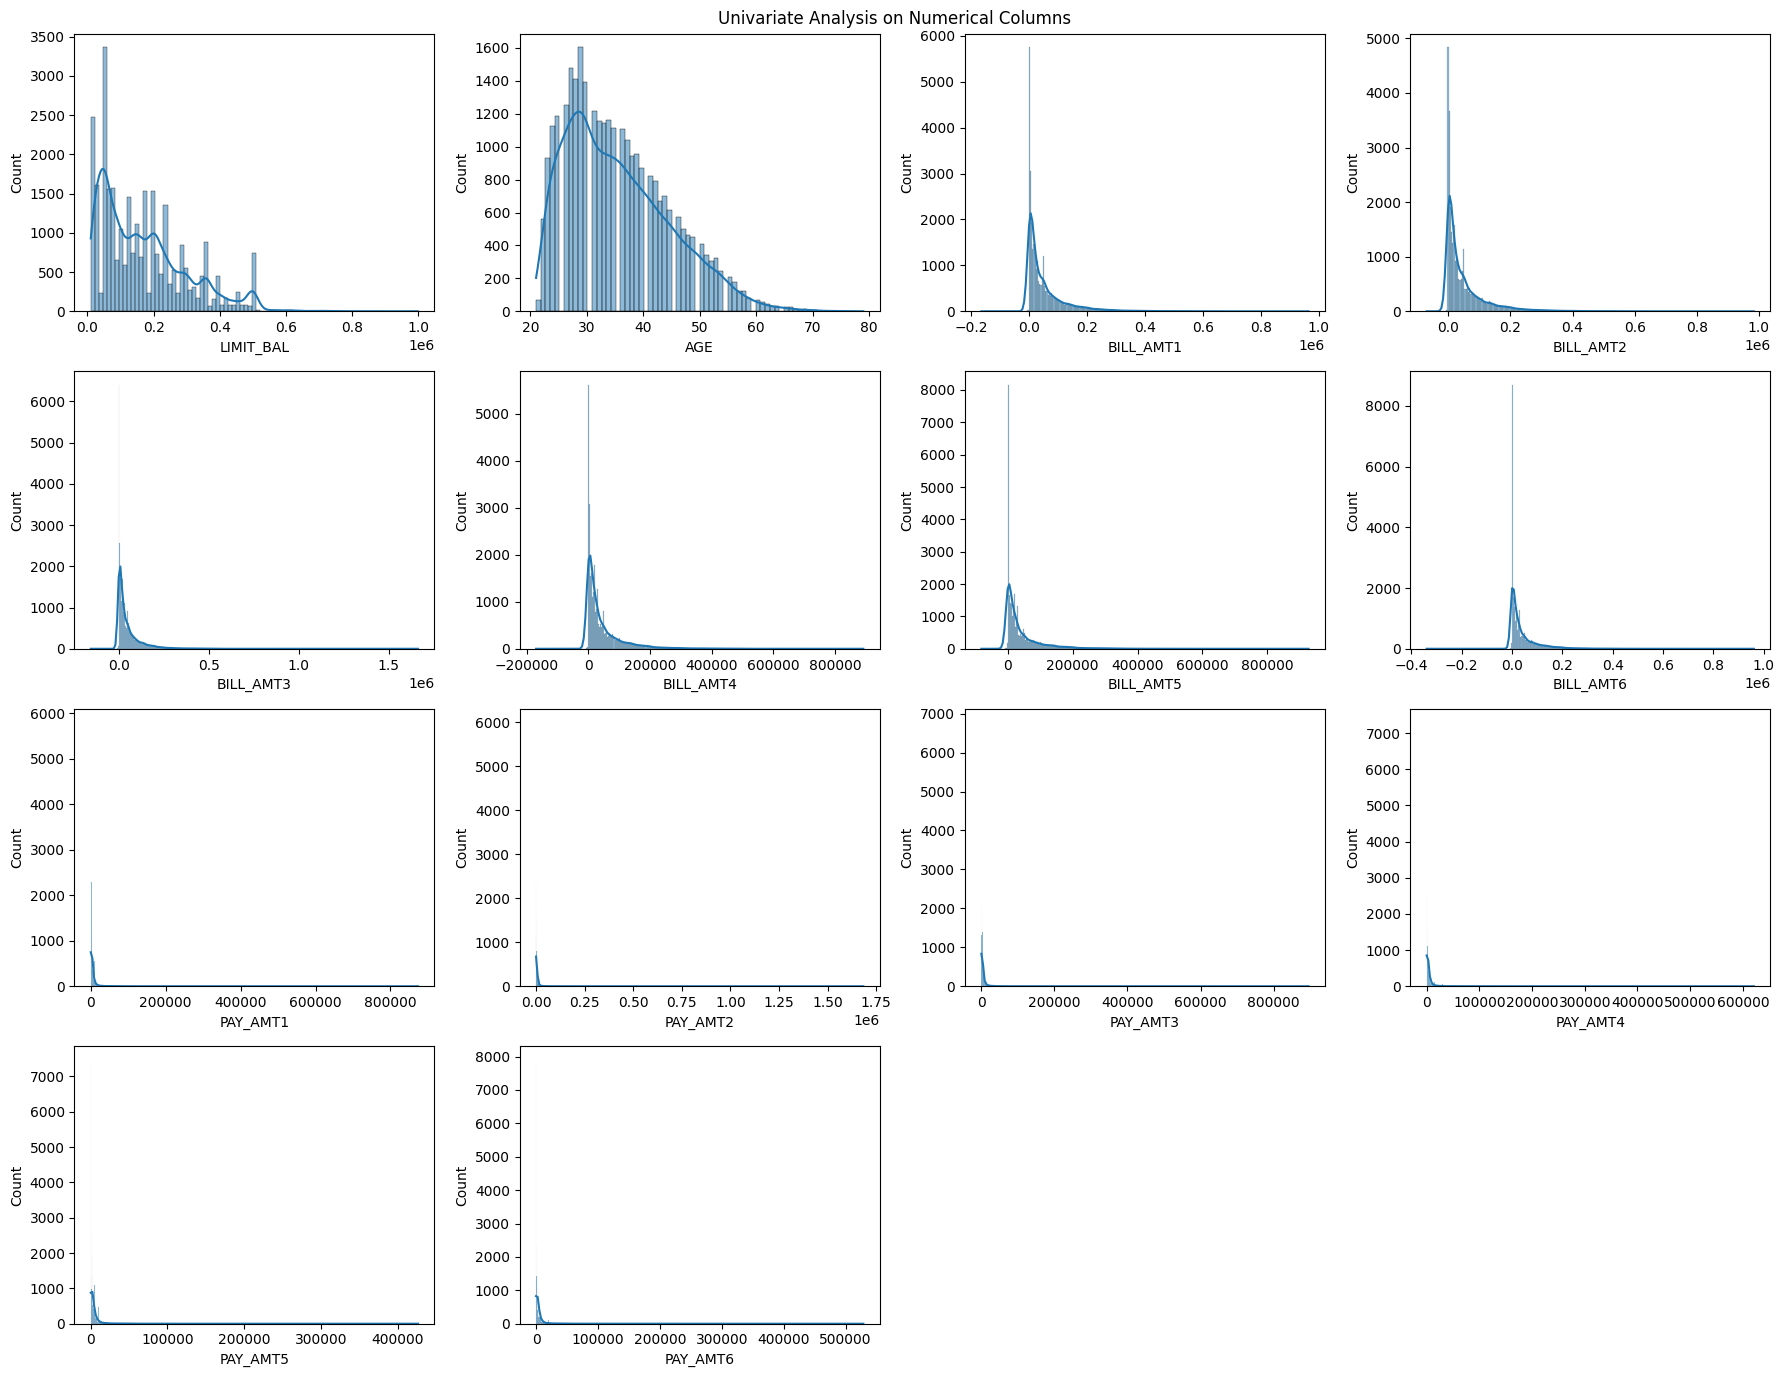

In [22]:
plt.rcParams["figure.figsize"] = (18, 14)

for i, col in enumerate(continous, start=1):
    plt.subplot(4, 4, i)
    sns.histplot(df[col], kde=True)

plt.suptitle("Univariate Analysis on Numerical Columns")
plt.tight_layout()
plt.show()

In [25]:
df[continous].skew()

LIMIT_BAL     0.992867
AGE           0.732246
BILL_AMT1     2.663861
BILL_AMT2     2.705221
BILL_AMT3     3.087830
BILL_AMT4     2.821965
BILL_AMT5     2.876380
BILL_AMT6     2.846645
PAY_AMT1     14.668364
PAY_AMT2     30.453817
PAY_AMT3     17.216635
PAY_AMT4     12.904985
PAY_AMT5     11.127417
PAY_AMT6     10.640727
dtype: float64

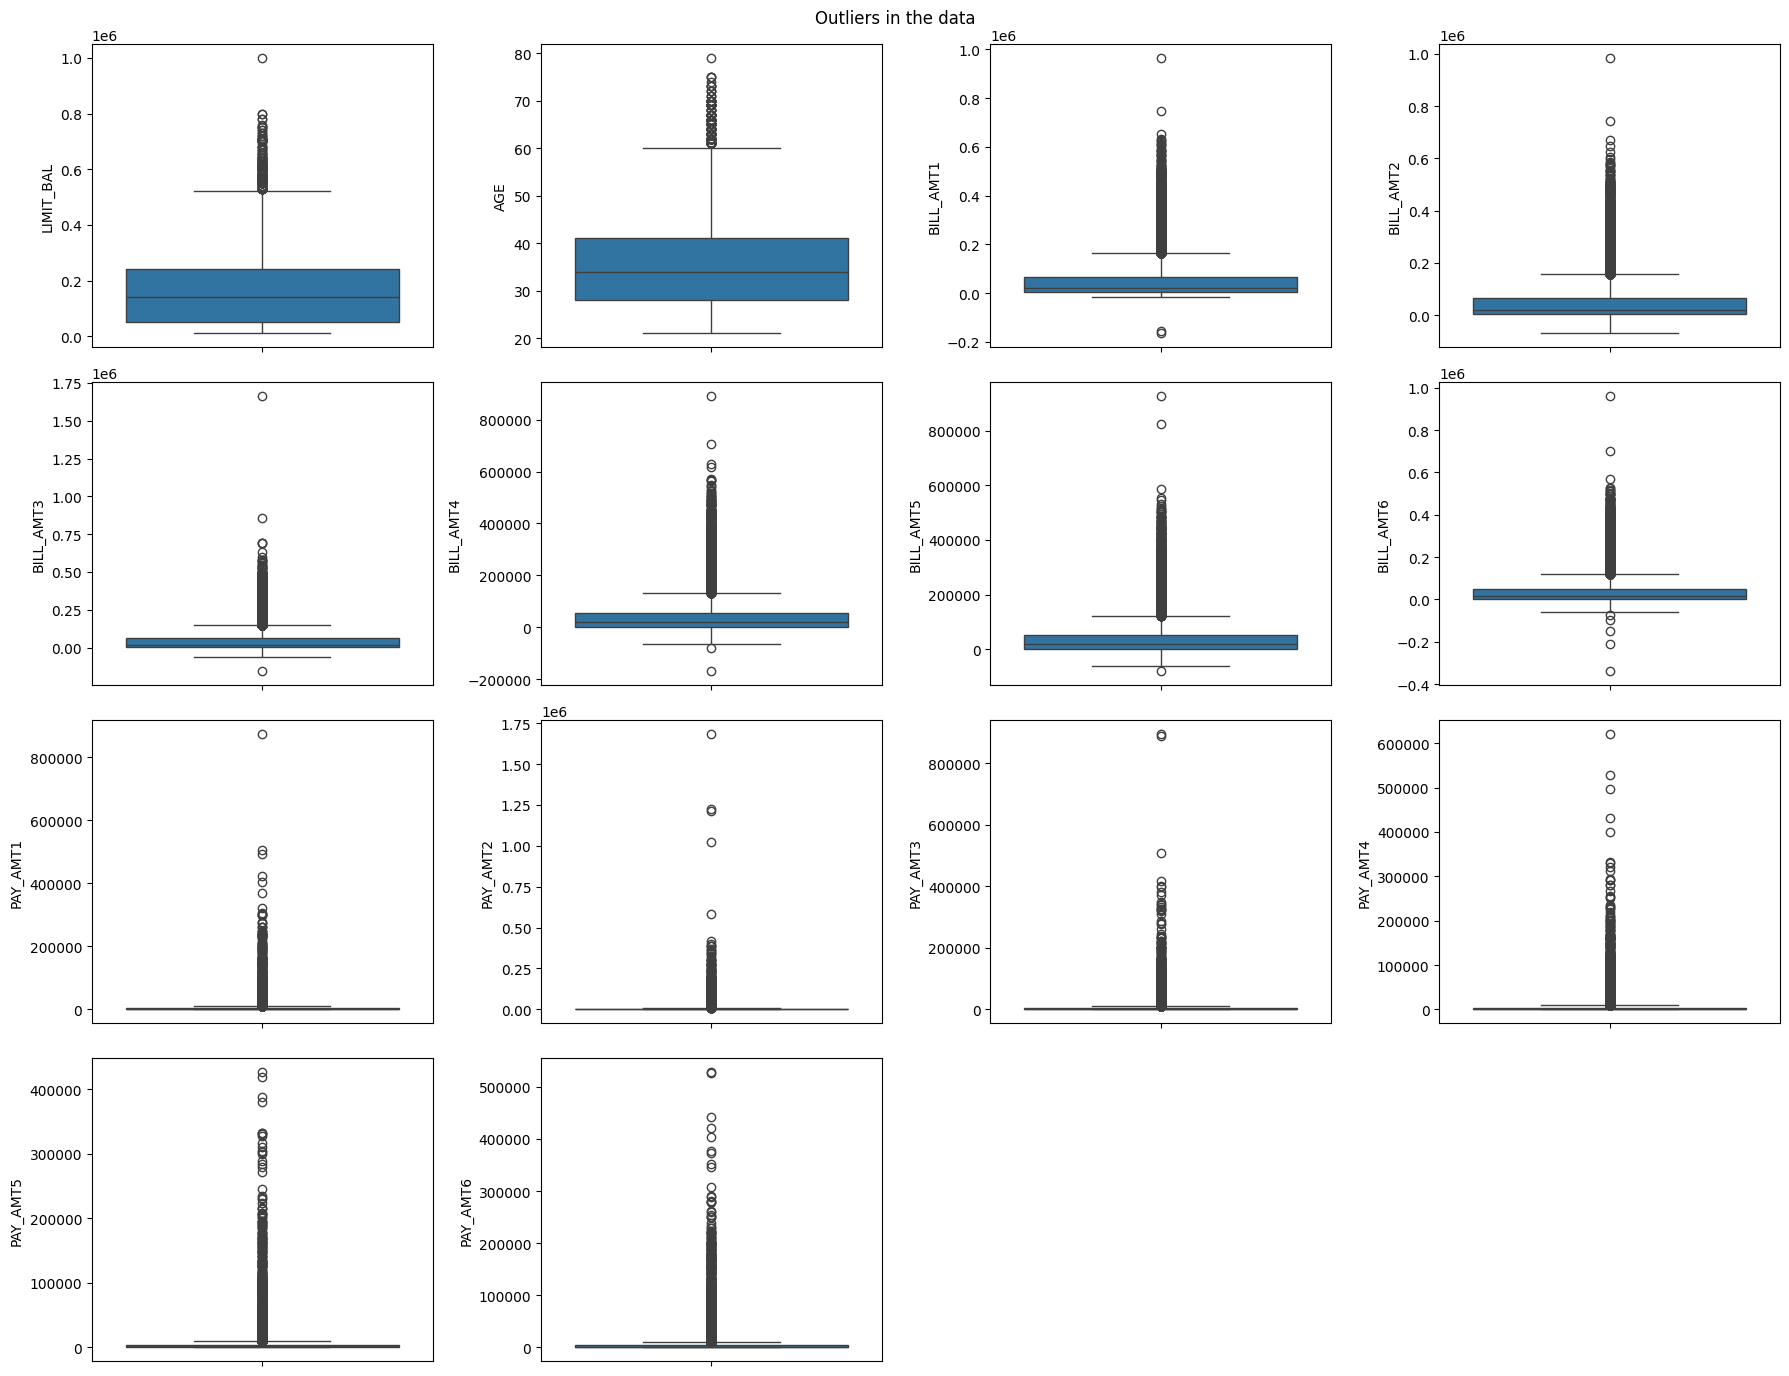

In [26]:
plt.rcParams["figure.figsize"] = (18, 14)
for i, col in enumerate(continous, start=1):
    plt.subplot(4, 4, i)
    sns.boxplot(df[col])
plt.suptitle("Outliers in the data")
plt.tight_layout()
plt.show()

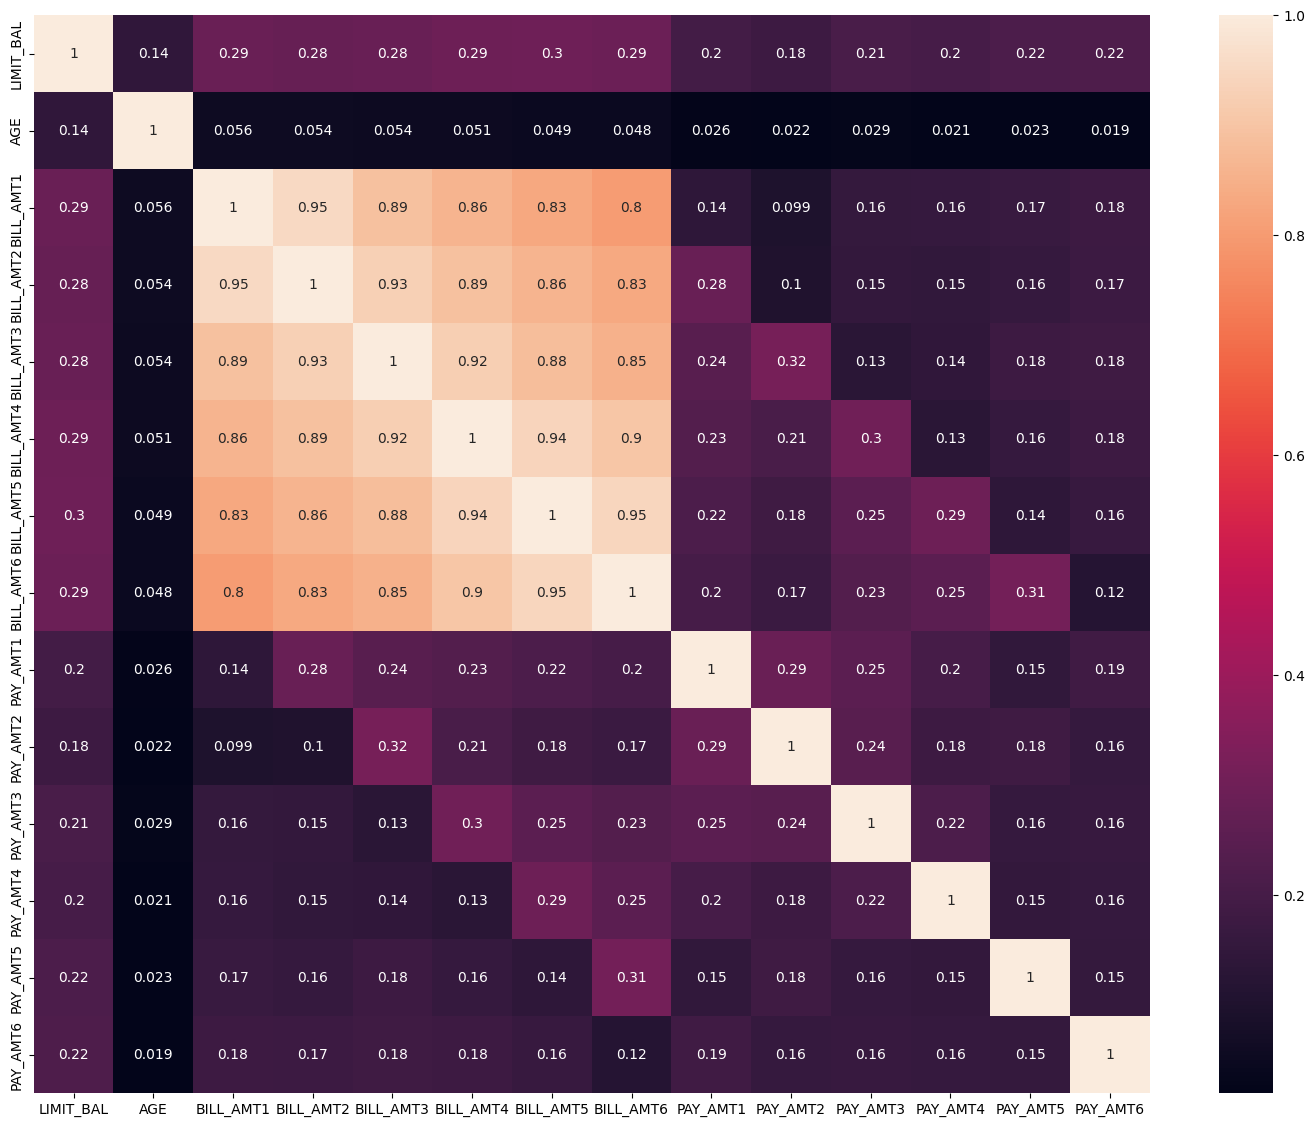

In [27]:
sns.heatmap(df[continous].corr(),annot=True)
plt.show()

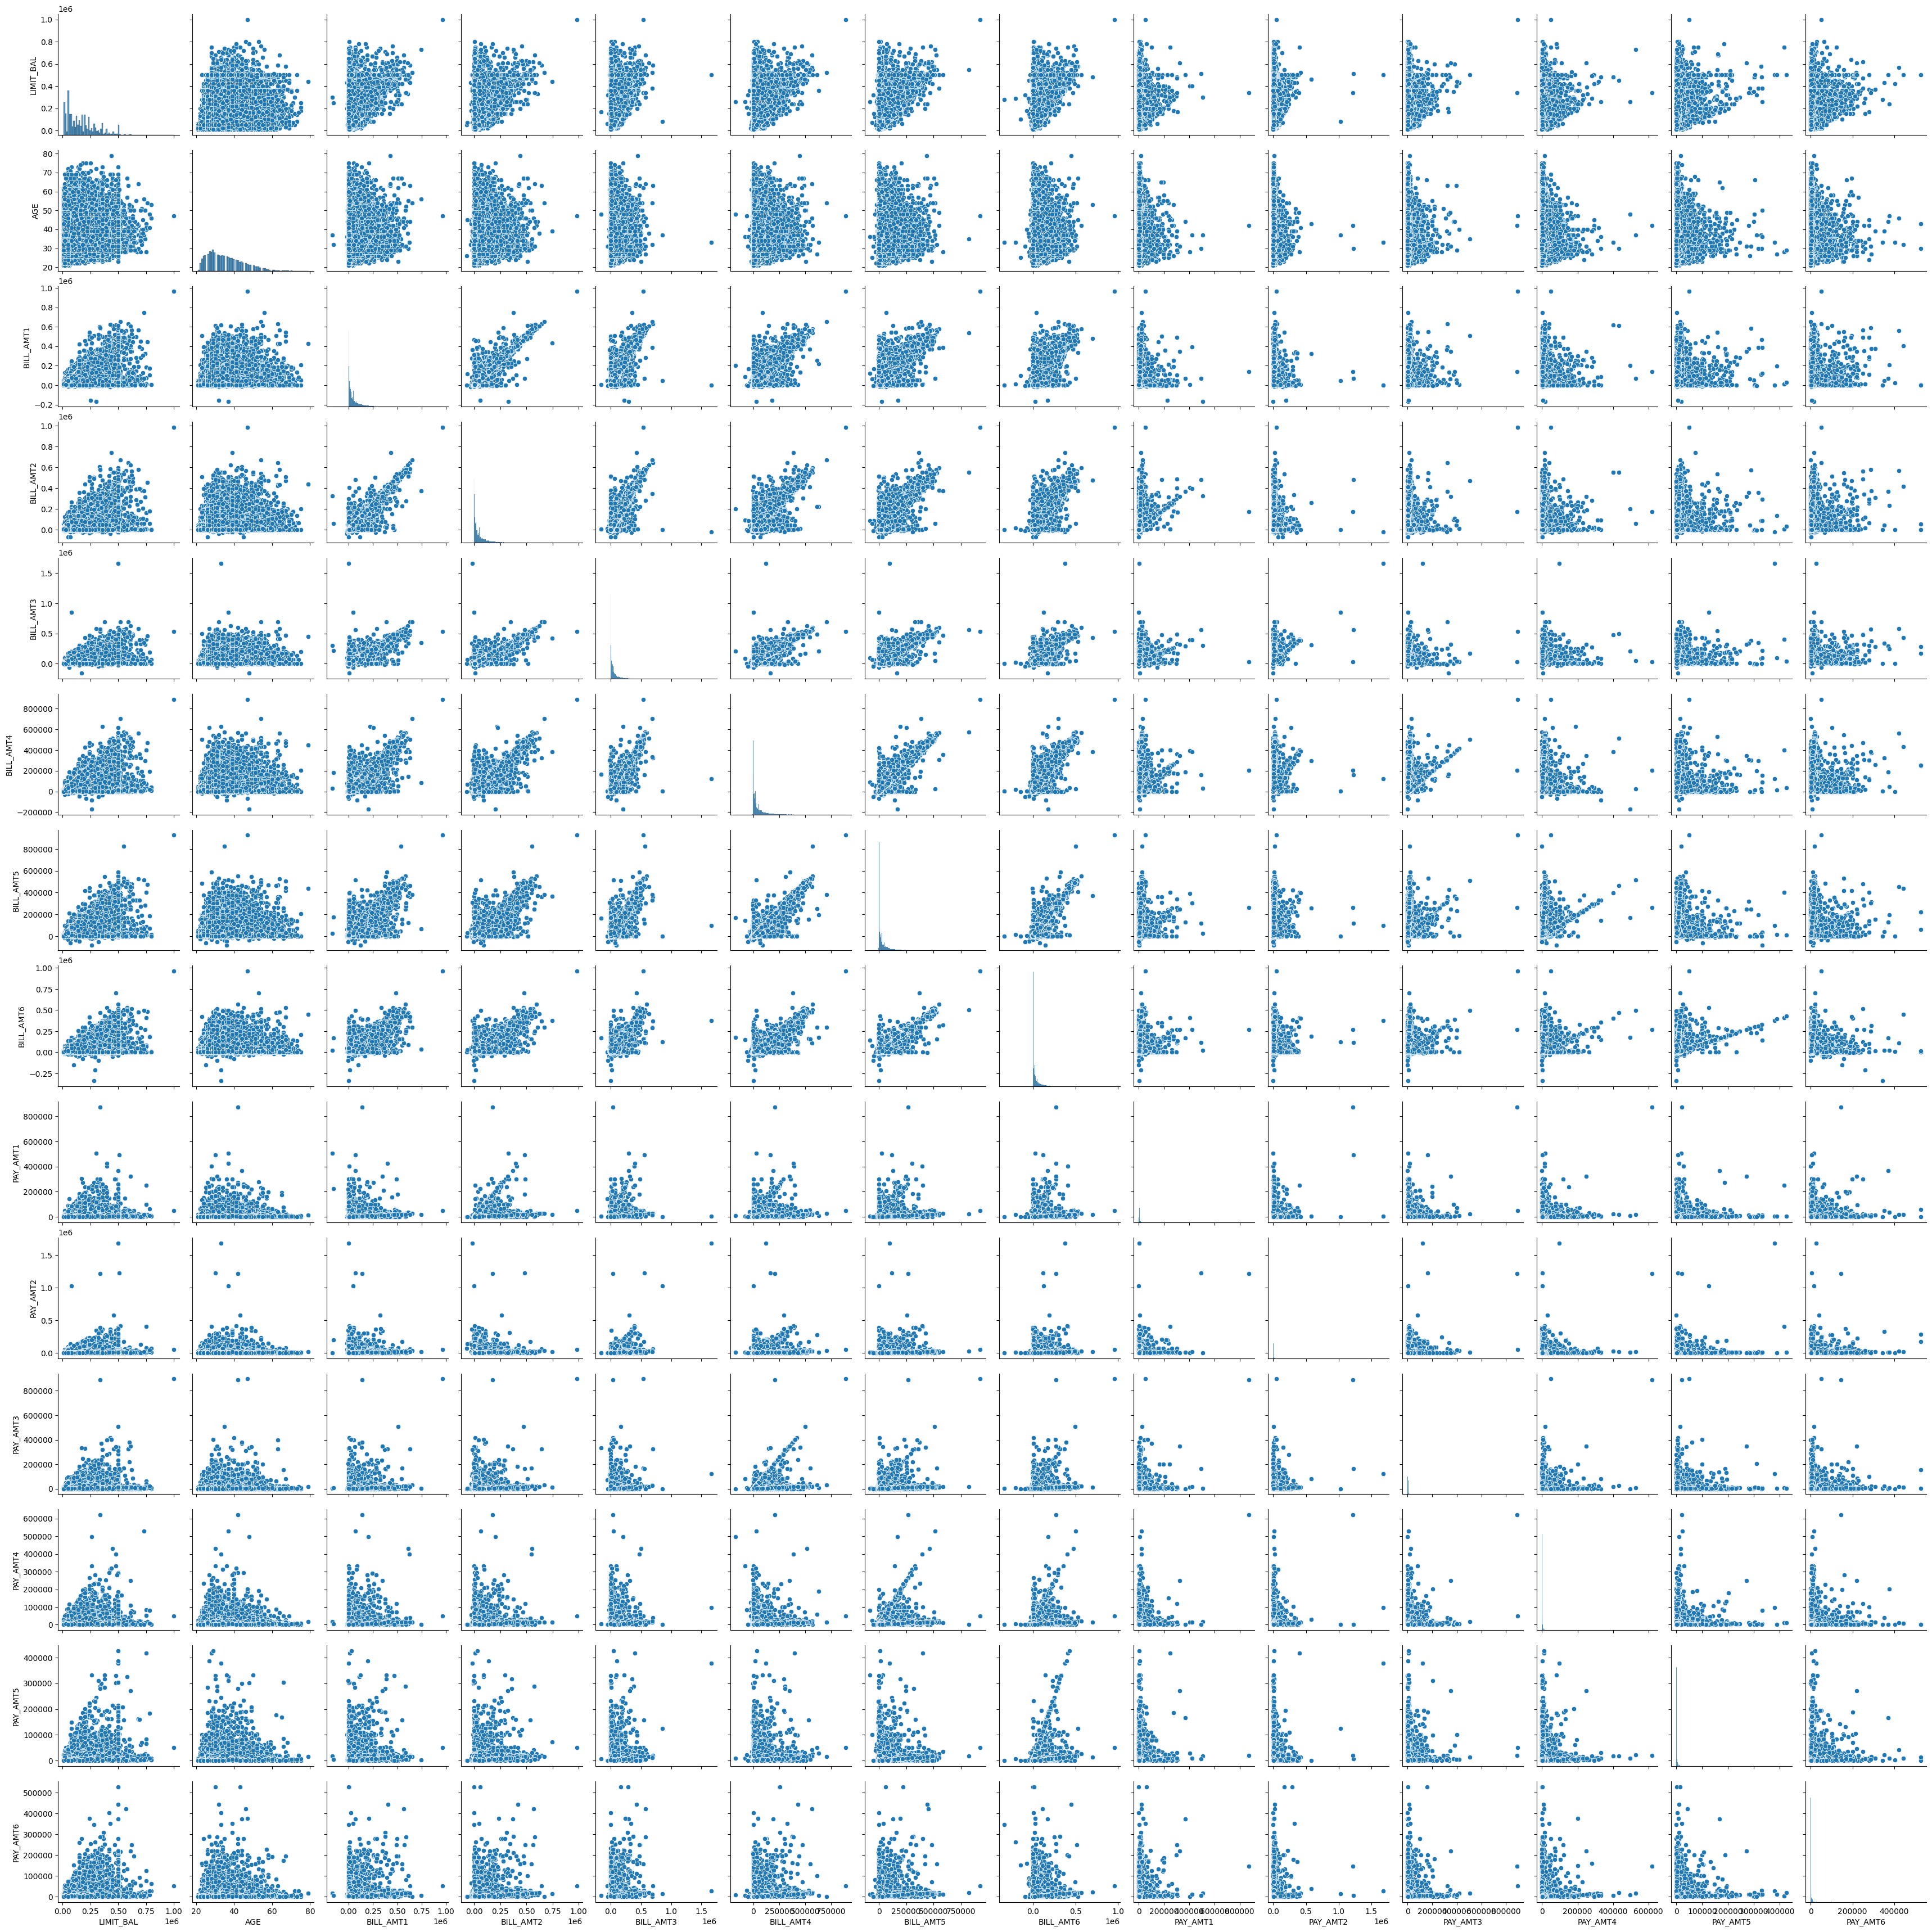

In [28]:
sns.pairplot(df[continous])
plt.show()

**For Discrete Variables**

In [29]:
df[discrete_categorical].describe()

,SEX,EDUCATION,MARRIAGE,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000
mean,1.603733,1.853133,1.551867,0.221200
std,0.489129,0.790349,0.521970,0.415062
min,1.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,0.000000
50%,2.000000,2.000000,2.000000,0.000000
75%,2.000000,2.000000,2.000000,0.000000
max,2.000000,6.000000,3.000000,1.000000


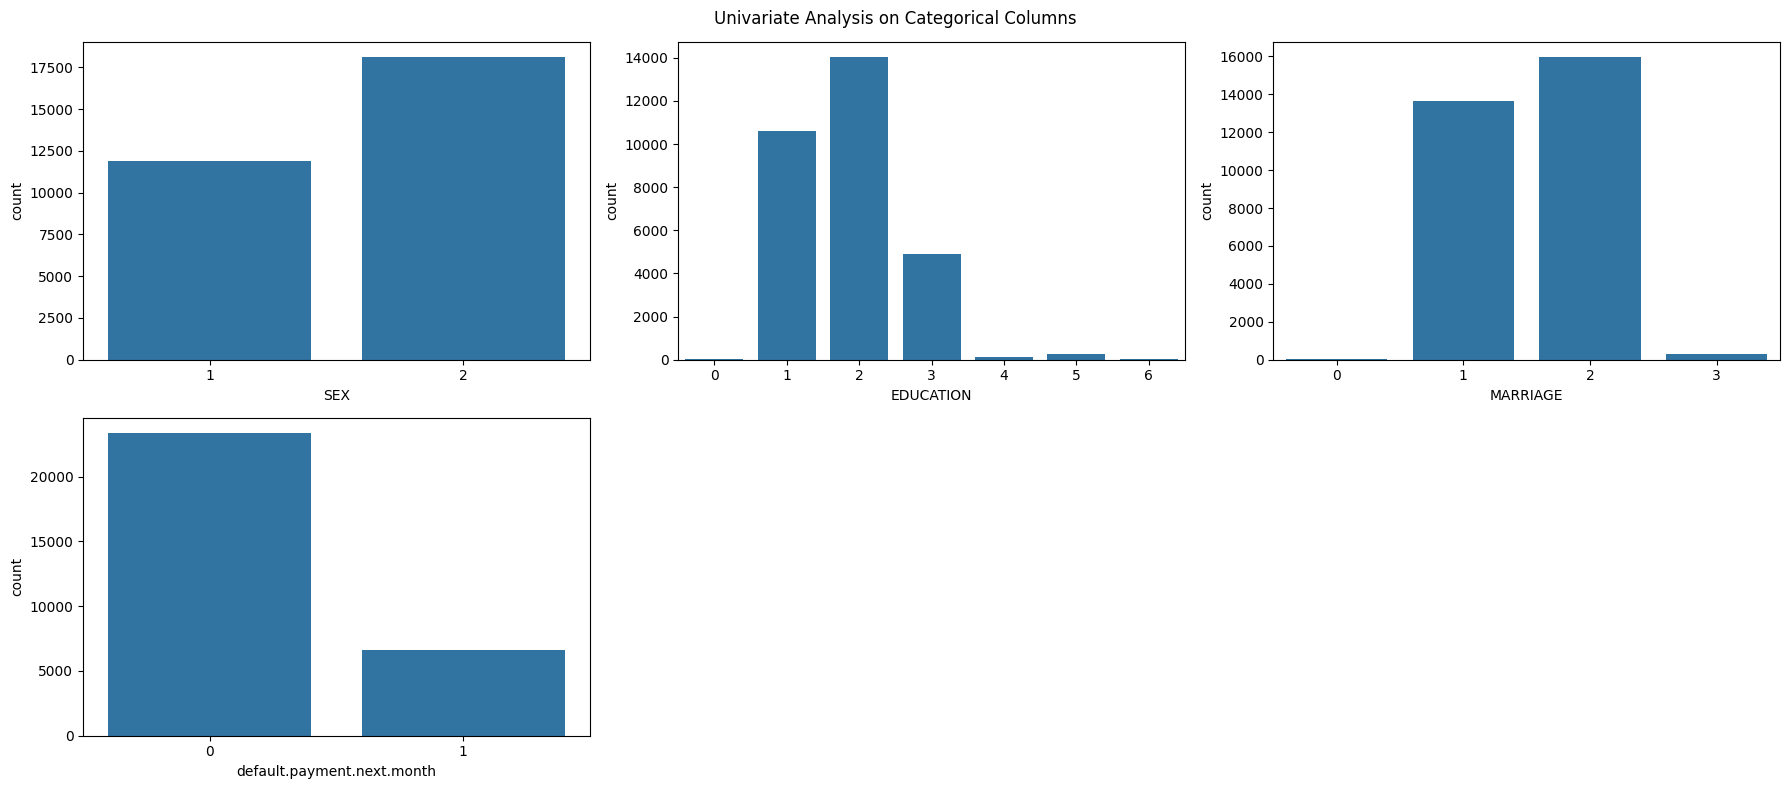

In [30]:
plt.rcParams["figure.figsize"] = (18, 8)

plt.subplot(2, 3, 1)
sns.countplot(x=df["SEX"])

plt.subplot(2, 3, 2)
sns.countplot(x=df["EDUCATION"])

plt.subplot(2, 3, 3)
sns.countplot(x=df["MARRIAGE"])

plt.subplot(2, 3, 4)
sns.countplot(x=df["default.payment.next.month"])

plt.suptitle("Univariate Analysis on Categorical Columns")
plt.tight_layout()
plt.show()

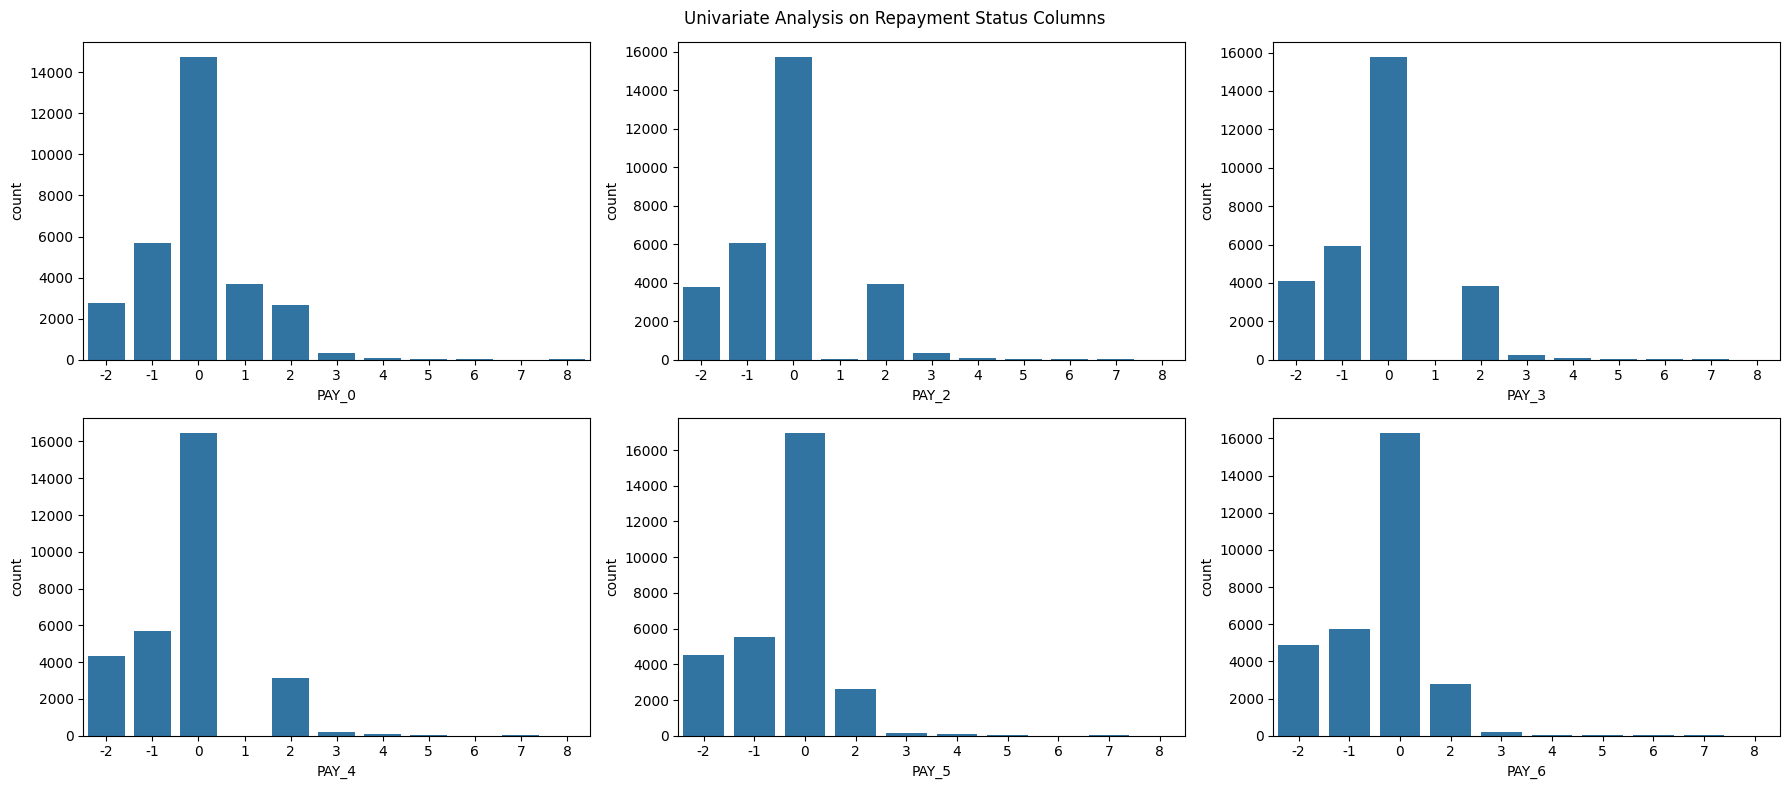

In [31]:
plt.rcParams["figure.figsize"] = (18, 8)

for i, col in enumerate(discrete_count, start=1):
    plt.subplot(2, 3, i)
    sns.countplot(x=df[col])

plt.suptitle("Univariate Analysis on Repayment Status Columns")
plt.tight_layout()
plt.show()

Note: the code `1` (one month delayed) appears only in `PAY_0`. Columns
`PAY_2` through `PAY_6` jump from 0 to 2, a known quirk of the UCI dataset.
This means `PAY_0` has finer resolution at low delinquency than the other
five months, and partly explains its stronger association with the target.

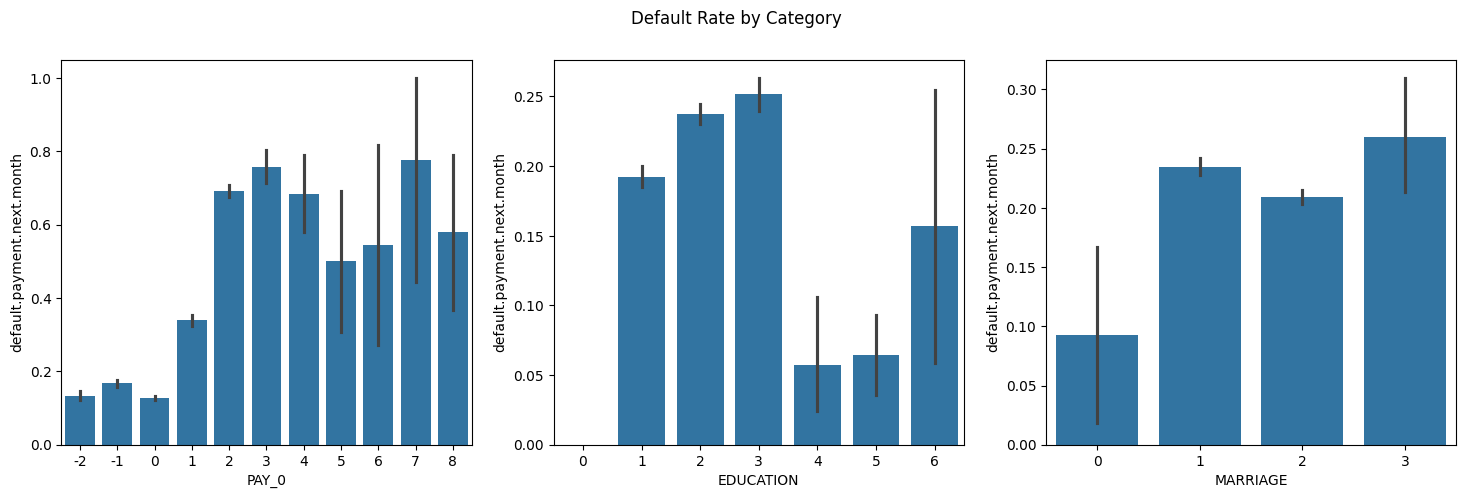

In [32]:
plt.rcParams["figure.figsize"] = (18, 5)
plt.subplot(1, 3, 1)
sns.barplot(x=df["PAY_0"], y=df["default.payment.next.month"])
plt.subplot(1, 3, 2)
sns.barplot(x=df["EDUCATION"], y=df["default.payment.next.month"])
plt.subplot(1, 3, 3)
sns.barplot(x=df["MARRIAGE"], y=df["default.payment.next.month"])
plt.suptitle("Default Rate by Category")
plt.show()

In [33]:
df.groupby("SEX")["default.payment.next.month"].agg(["mean", "size"])

,mean,size
SEX,,
1,0.241672,11888
2,0.207763,18112


**Check For Missing Values**

In [34]:
df.isnull().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [35]:
df.duplicated().sum()

np.int64(35)

## Stage 3: Data Preparation

### 3.1 Cleaning (stateless — applied before split)
    - Wrong data: EDUCATION, MARRIAGE undocumented codes
    - Duplicates: 35 rows
    - Missing values: none present
    - Outliers: examined, retained (justification)
    - Drop ID

### 3.2 Feature Engineering (stateless — applied before split)
    - months_delinquent, max_delinquency, over_limit

### 3.3 Wrangling Strategy (documented here, EXECUTED in pipeline after split)
    - Transformation: Yeo-Johnson on skewed columns, and why not Box-Cox
    - Scaling: StandardScaler, and which models need it
    - Encoding: one-hot for nominal, passthrough for ordinal
    - Feature exclusions: SEX, MARRIAGE on Equality Act grounds

**Wrong data treatment**

In [36]:
# EDUCATION: codebook defines 1-4. Values 0, 5, 6 (345 rows) are
# undocumented — grouped into 4 (Others)
df["EDUCATION"] = df["EDUCATION"].replace([0, 5, 6], 4)

In [37]:
# MARRIAGE: codebook defines 1-3. Value 0 (54 rows) is undocumented
# — grouped into 3 (Others)
df["MARRIAGE"] = df["MARRIAGE"].replace(0, 3)

In [38]:
# Confirm the fix
df["EDUCATION"].value_counts().sort_index()

EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

In [39]:
df["MARRIAGE"].value_counts().sort_index()

MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64

**Missing Values Treatment**

In [40]:
# No missing values present — no treatment required
df.isnull().sum().sum()

np.int64(0)

**Data type conversion**

In [41]:
# All columns numeric, no conversion required
df.dtypes.value_counts()

float64    13
int64      11
Name: count, dtype: int64

**Duplicates**

In [42]:
df.duplicated().sum()

np.int64(35)

In [43]:
df = df.drop_duplicates()
df.shape

(29965, 24)

**Outlier Treatment**

# Outliers examined during EDA and retained.
# In consumer credit, extreme values are legitimate customers rather than
# measurement errors: a NT$1,000,000 credit limit is a wealthy client,
# a NT$873,552 payment is someone clearing a large balance. These are
# precisely the accounts where default is most costly, so removing them
# would discard the rows the model exists to identify.

## 3.2 Feature Engineering

In [44]:
# months_delinquent: how many of the last six months were late?
# PAY_* codes: -2 no consumption, -1 paid in full, 0 revolving,
# 1-8 months delayed. So > 0 means late.
df["months_delinquent"] = (df[discrete_count] > 0).sum(axis=1)

In [45]:
# max_delinquency: worst delinquency observed in the six-month window
df["max_delinquency"] = df[discrete_count].max(axis=1)

In [46]:
# over_limit: balance exceeds the credit limit. Found in 1,583 rows (5.3%)
# during EDA, defaulting at 30.1% against a 21.5% base rate.
df["over_limit"] = (df["BILL_AMT1"] > df["LIMIT_BAL"]).astype(int)

In [47]:
df.groupby("months_delinquent")["default.payment.next.month"].agg(["mean", "size"])

,mean,size
months_delinquent,,
0,0.117130,19918
1,0.298751,4405
2,0.387572,1899
3,0.508666,1154
4,0.573081,951
5,0.573826,298
6,0.702985,1340


In [48]:
df.groupby("over_limit")["default.payment.next.month"].agg(["mean", "size"])

,mean,size
over_limit,,
0,0.215224,27850
1,0.300709,2115


In [49]:
df[["months_delinquent", "max_delinquency", "over_limit"]].corrwith(
    df["default.payment.next.month"]
)

months_delinquent    0.398406
max_delinquency      0.331082
over_limit           0.052747
dtype: float64

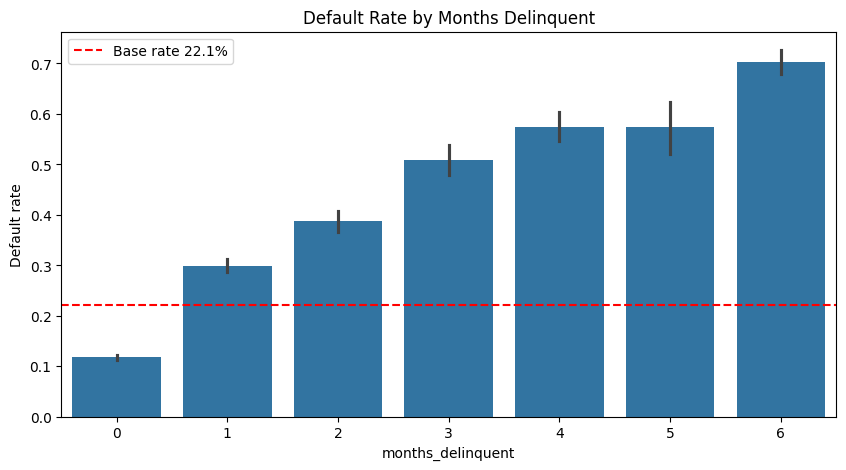

In [50]:
plt.rcParams["figure.figsize"] = (10, 5)
sns.barplot(x=df["months_delinquent"], y=df["default.payment.next.month"])
plt.axhline(0.2212, color="red", linestyle="--", label="Base rate 22.1%")
plt.title("Default Rate by Months Delinquent")
plt.ylabel("Default rate")
plt.legend()
plt.show()

In [51]:
engineered = ["months_delinquent", "max_delinquency", "over_limit"]

### 3.3 Wrangling Strategy

Transformation, scaling and encoding are **decided here but executed in the
pipeline after the train/test split**, because all three learn parameters
from the data (a lambda, a mean and standard deviation, a category
vocabulary). Fitting them on the full dataset would leak test information
into training.

**Transformation** — Yeo-Johnson on `LIMIT_BAL`, `BILL_AMT1-6`, `PAY_AMT1-6`.
Box-Cox was rejected: it requires strictly positive input, and 590 rows have
a negative `BILL_AMT1` (customers in credit). Yeo-Johnson is the same
power-transform family and handles zeros and negatives.

**Scaling** — StandardScaler. Required for logistic regression, which uses
gradient descent and is sensitive to feature magnitude. Tree ensembles are
invariant to monotonic transforms and unaffected. Applied uniformly so all
candidate models are compared under identical preprocessing.

**Encoding**
- `EDUCATION`, `MARRIAGE` — nominal, one-hot with `drop='first'` and
  `handle_unknown='ignore'`. EDA confirmed no valid ordering: categories 4
  and 5 default at 5.6% and 6.4%, below graduates at 19%.
- `PAY_0`–`PAY_6` — ordinal, passed through as integers. One-hot would
  discard the ordering, and codes 5–8 have only 65 rows between them.
- `months_delinquent`, `over_limit` — counts, passed through unscaled.

**Feature exclusions** — `SEX` and `MARRIAGE` are protected characteristics
under the Equality Act 2010; using them in a credit decision would be direct
discrimination in a UK context. Predictive contribution is marginal (24.2%
vs 20.8% default by sex, against a 22.1% base rate). `AGE` is retained:
financial services has a specific exemption for age-based risk assessment.

## 4. Train/Test Split

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
X = df.drop(columns=["default.payment.next.month"])
y = df["default.payment.next.month"]

print(X.shape, y.shape)

(29965, 26) (29965,)


In [54]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(X_train.shape, X_test.shape)

(23972, 26) (5993, 26)


In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

In [56]:
from sklearn.metrics import (
    average_precision_score,   # your ranking metric
    roc_auc_score,
    classification_report,
    confusion_matrix,
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import cross_val_predict   # for the threshold sweep
import joblib                                            # for saving

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer

In [58]:
skewed = ["LIMIT_BAL"] + [f"BILL_AMT{i}" for i in range(1, 7)] \
                       + [f"PAY_AMT{i}" for i in range(1, 7)]

plain_numeric = ["AGE", "months_delinquent", "max_delinquency", "over_limit"]

nominal = ["SEX", "EDUCATION", "MARRIAGE"]

ordinal = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

In [59]:
print(len(skewed + plain_numeric + nominal + ordinal), "vs", X_train.shape[1])

26 vs 26


In [60]:
preprocessor = ColumnTransformer([
    ("skew", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("power", PowerTransformer(method="yeo-johnson")),
    ]), skewed),

    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), plain_numeric),

    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), nominal),

    ("ord", "passthrough", ordinal),
])

In [61]:
tmp = preprocessor.fit_transform(X_train)
print(tmp.shape)

(23972, 29)


In [62]:
#modelling
log_model = Pipeline([("prep", preprocessor),
                      ("model", LogisticRegression(max_iter=2000, random_state=42))])
log_model.fit(X_train, y_train)

#predict & Evaluate on train data
ypred_train = log_model.predict(X_train)
print("Train Accuracy:", accuracy_score(y_train, ypred_train))
print("Train AP:", average_precision_score(y_train, log_model.predict_proba(X_train)[:, 1]))

#Cross Validation on Train Data
print("CV Accuracy:", cross_val_score(log_model, X_train, y_train, cv=5, scoring="accuracy").mean())
print("CV AP:", cross_val_score(log_model, X_train, y_train, cv=5, scoring="average_precision").mean())

Train Accuracy: 0.8081511763724345
Train AP: 0.5109009693764424
CV Accuracy: 0.8072332073068396
CV AP: 0.5073263611855515


# 2.Decision Tree

In [63]:
model = DecisionTreeClassifier(random_state=42)
dt_base = Pipeline([("prep", preprocessor), ("model", model)])
dt_base.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('skew', ...), ('num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


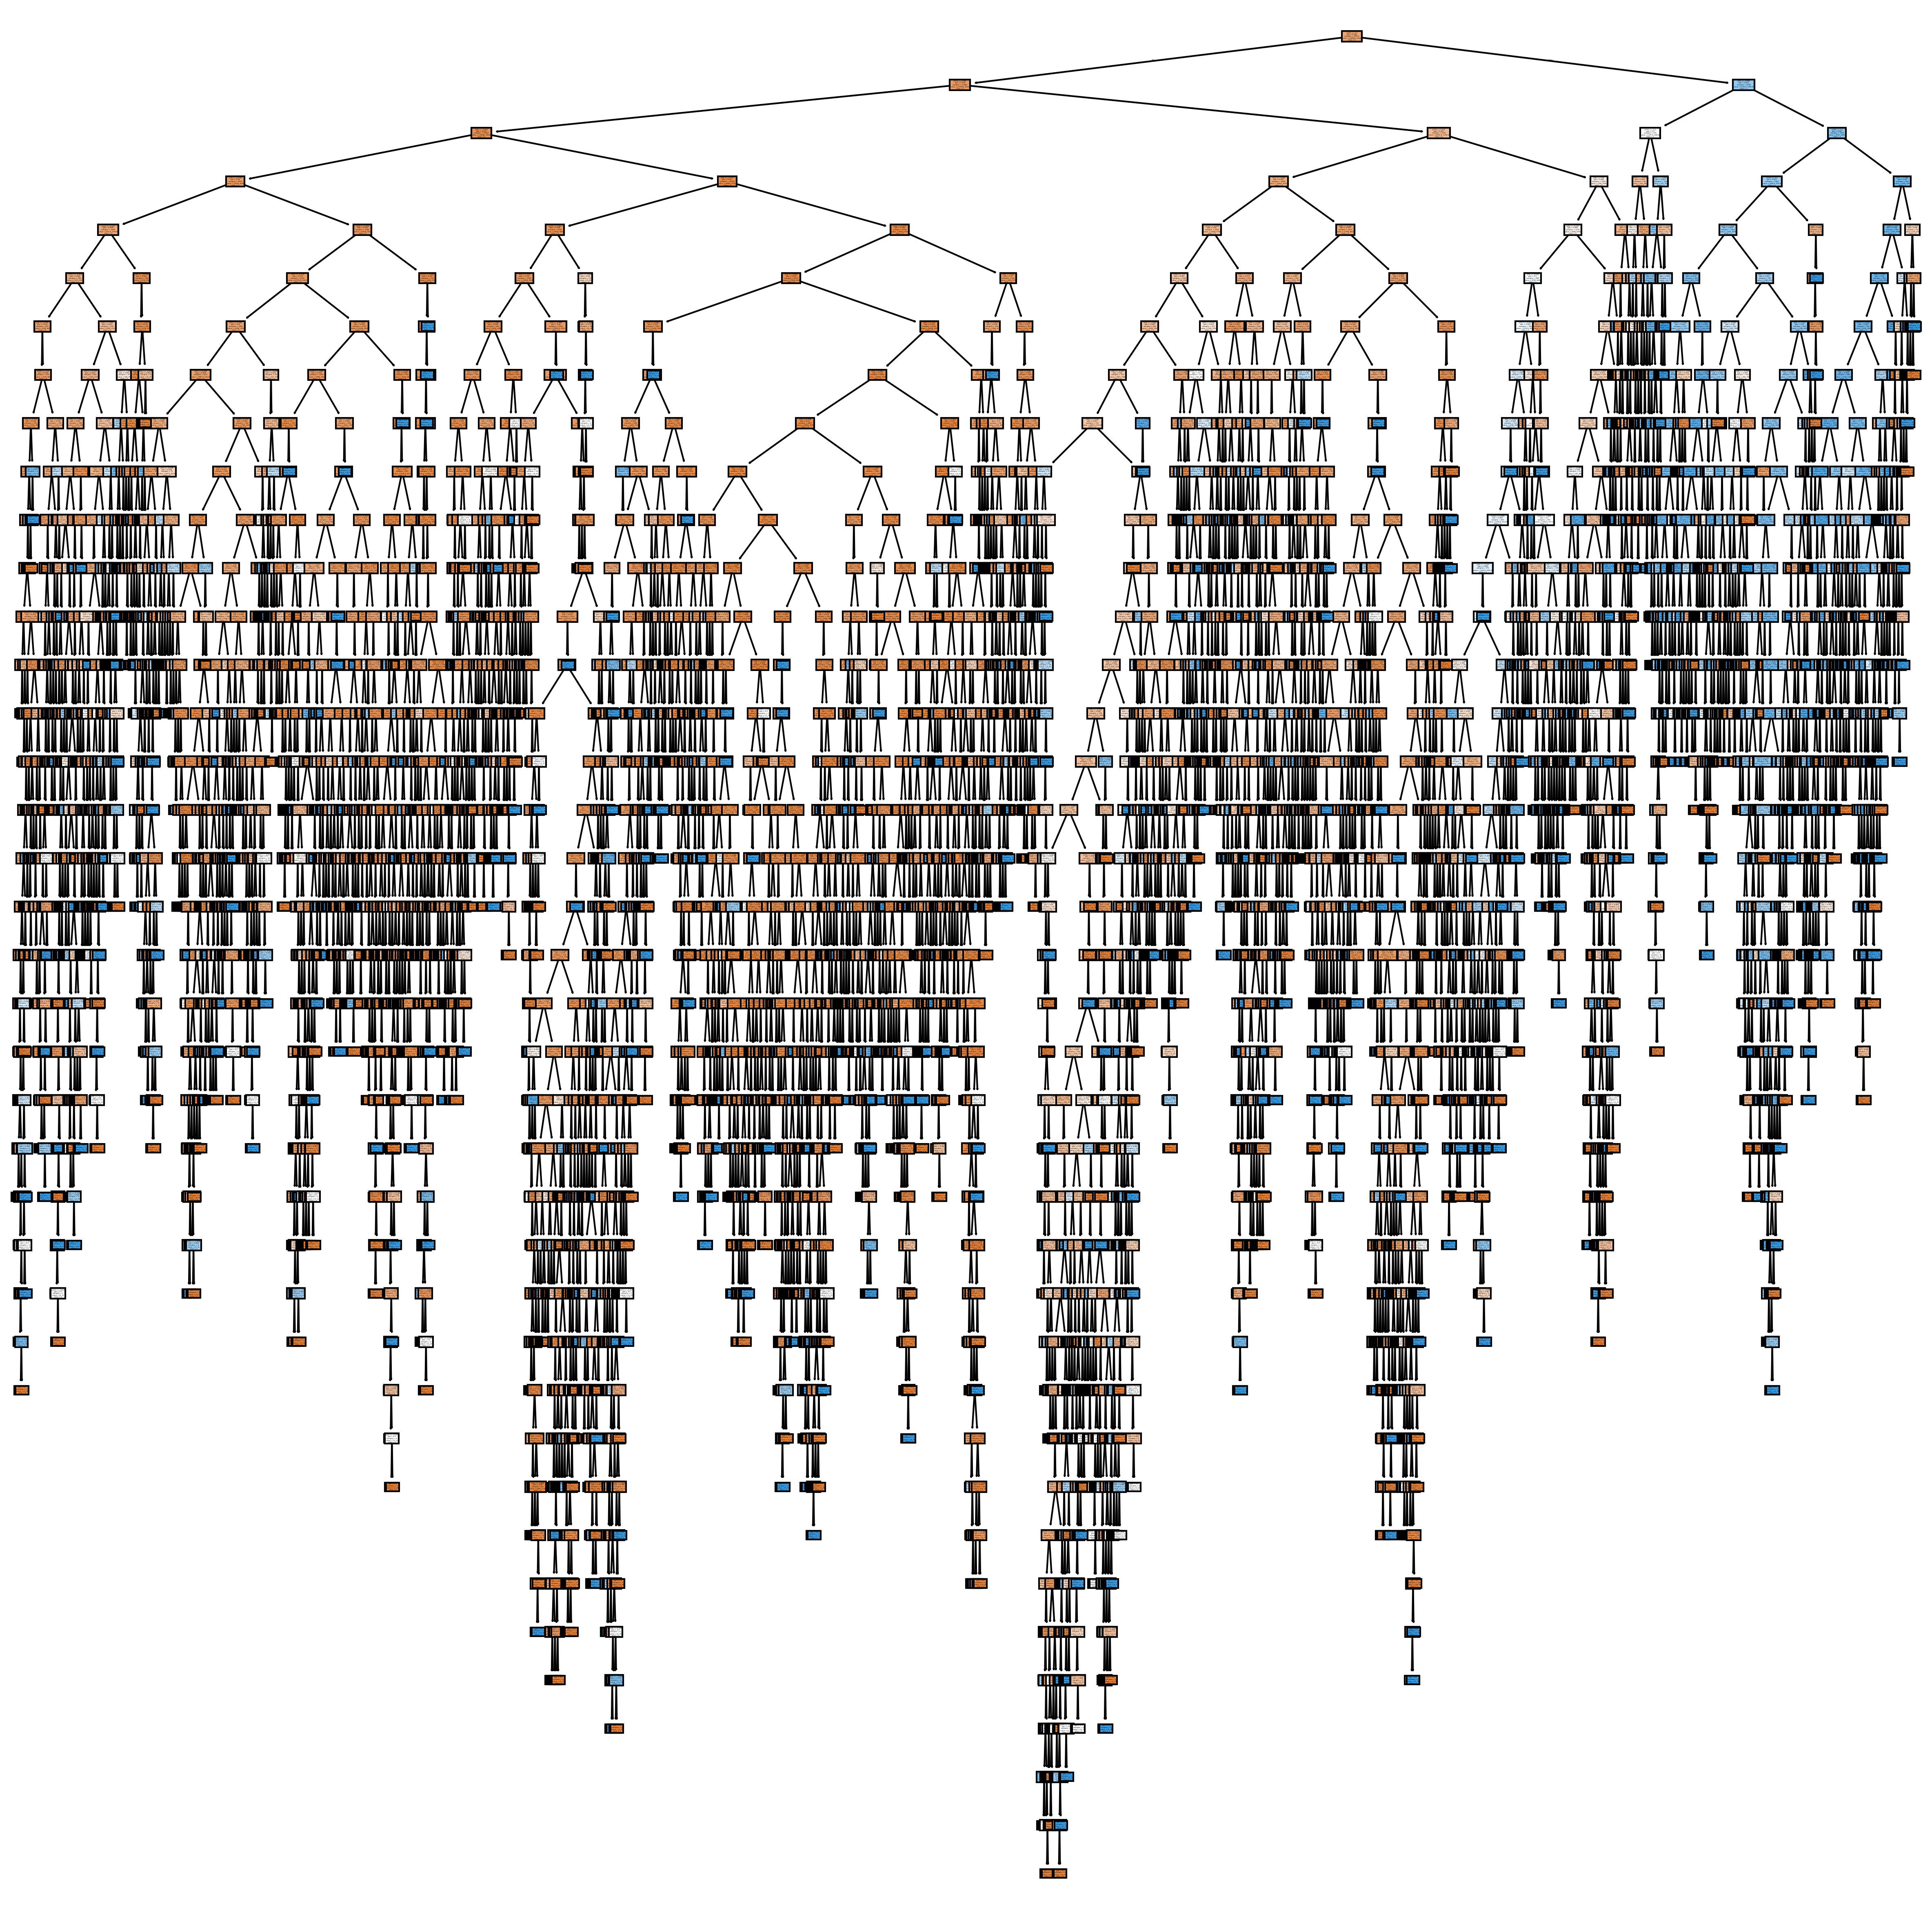

In [64]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 20), dpi=300)
plot_tree(dt_base.named_steps["model"], filled=True,
          class_names=["0", "1"])
plt.show()

In [65]:
print(dt_base.named_steps["model"].get_depth())

38


In [66]:
#hyperparameter Tuning
param_grid = {"model__criterion": ["gini", "entropy"],
              "model__max_depth": list(range(1, 39))}

dt_grid = GridSearchCV(dt_base, param_grid, scoring="average_precision", cv=5, n_jobs=-1)
dt_grid.fit(X_train, y_train)

dt = dt_grid.best_estimator_
print(dt_grid.best_params_)
print("Best CV AP:", dt_grid.best_score_)

{'model__criterion': 'entropy', 'model__max_depth': 6}
Best CV AP: 0.5233754105903827


In [67]:
#Important features
feats_dt = pd.DataFrame(data=dt.named_steps["model"].feature_importances_,
                        index=dt.named_steps["prep"].get_feature_names_out(),
                        columns=["Importance"])
feats_dt.sort_values("Importance", ascending=False).head(15)

,Importance
ord__PAY_0,0.570285
num__max_delinquency,0.189347
skew__PAY_AMT2,0.045148
num__months_delinquent,0.038488
skew__LIMIT_BAL,0.025970
skew__BILL_AMT1,0.025110
skew__BILL_AMT2,0.016306
skew__PAY_AMT1,0.014358
num__over_limit,0.010531
skew__PAY_AMT4,0.010047


In [68]:
#Modelling and Evaluation
ypred_train = dt.predict(X_train)
print("Train Accuracy:", accuracy_score(y_train, ypred_train))
print("Train AP:", average_precision_score(y_train, dt.predict_proba(X_train)[:, 1]))
print("CV Accuracy:", cross_val_score(dt, X_train, y_train, cv=5, scoring="accuracy").mean())
print("CV AP:", cross_val_score(dt, X_train, y_train, cv=5, scoring="average_precision").mean())

Train Accuracy: 0.8254630402135825
Train AP: 0.5643691745252828
CV Accuracy: 0.8184131450374839
CV AP: 0.5233754105903827


In [69]:
#Random Forest Classifier

In [70]:
#Random Forest Classifier
model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_base = Pipeline([("prep", preprocessor), ("model", model)])
rf_base.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('skew', ...), ('num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [71]:
#Hyperparameter Tuning
param_grid = {"model__n_estimators": [200, 300],
              "model__max_depth": [6, 10, 15, None],
              "model__min_samples_leaf": [1, 5, 20]}

rf_grid = GridSearchCV(rf_base, param_grid, scoring="average_precision", cv=5)
rf_grid.fit(X_train, y_train)

rf = rf_grid.best_estimator_
print(rf_grid.best_params_)
print("Best CV AP:", rf_grid.best_score_)

{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Best CV AP: 0.5637792192366746


In [72]:
#Important features
feats_rf = pd.DataFrame(data=rf.named_steps["model"].feature_importances_,
                        index=rf.named_steps["prep"].get_feature_names_out(),
                        columns=["Importance"])
feats_rf.sort_values("Importance", ascending=False).head(15)

,Importance
ord__PAY_0,0.186755
num__months_delinquent,0.106501
num__max_delinquency,0.099601
ord__PAY_2,0.070959
ord__PAY_3,0.037598
skew__BILL_AMT1,0.036735
skew__PAY_AMT1,0.035101
skew__LIMIT_BAL,0.033212
ord__PAY_4,0.030951
skew__BILL_AMT2,0.030654


In [73]:
#Modelling and Evaluation
ypred_train = rf.predict(X_train)
print("Train Accuracy:", accuracy_score(y_train, ypred_train))
print("Train AP:", average_precision_score(y_train, rf.predict_proba(X_train)[:, 1]))
print("CV Accuracy:", cross_val_score(rf, X_train, y_train, cv=5, scoring="accuracy").mean())
print("CV AP:", cross_val_score(rf, X_train, y_train, cv=5, scoring="average_precision").mean())

Train Accuracy: 0.8534123143667612
Train AP: 0.7247515419053708
CV Accuracy: 0.8196230428807645
CV AP: 0.5637792192366746


In [74]:
res = pd.DataFrame(rf_grid.cv_results_)
res[["param_model__max_depth", "param_model__min_samples_leaf",
     "param_model__n_estimators", "mean_test_score", "std_test_score"]] \
    .sort_values("mean_test_score", ascending=False).head(8)

,param_model__max_depth,param_model__min_samples_leaf,param_model__n_estimators,mean_test_score,std_test_score
6,10,1,200,0.563779,0.022494
7,10,1,300,0.563616,0.022772
8,10,5,200,0.563420,0.021934
9,10,5,300,0.563199,0.022038
17,15,20,300,0.561634,0.021002
16,15,20,200,0.561608,0.021312
23,None,20,300,0.561148,0.020949
11,10,20,300,0.561088,0.020841


In [75]:
rf = Pipeline([("prep", preprocessor),
               ("model", RandomForestClassifier(n_estimators=300, max_depth=10,
                                                min_samples_leaf=20,
                                                random_state=42, n_jobs=-1))])
rf.fit(X_train, y_train)
print("Train AP:", average_precision_score(y_train, rf.predict_proba(X_train)[:, 1]))
print("CV AP:", cross_val_score(rf, X_train, y_train, cv=5, scoring="average_precision").mean())

Train AP: 0.6484408099655607
CV AP: 0.5610883007243408


# AdaBoost

In [76]:
#AdaBoost Classifier
model = AdaBoostClassifier(random_state=42)
ab_base = Pipeline([("prep", preprocessor), ("model", model)])

In [77]:
#Hyperparameter Tuning
param_grid = {"model__n_estimators": [50, 100, 200],
              "model__learning_rate": [0.1, 0.5, 1.0]}

ab_grid = GridSearchCV(ab_base, param_grid, scoring="average_precision", cv=5, n_jobs=-1)
ab_grid.fit(X_train, y_train)

ab = ab_grid.best_estimator_
print(ab_grid.best_params_)
print("Best CV AP:", ab_grid.best_score_)

{'model__learning_rate': 1.0, 'model__n_estimators': 200}
Best CV AP: 0.5413714147317983


In [78]:
#Modelling and Evaluation
ypred_train = ab.predict(X_train)
print("Train AP:", average_precision_score(y_train, ab.predict_proba(X_train)[:, 1]))
print("CV AP:", cross_val_score(ab, X_train, y_train, cv=5, scoring="average_precision").mean())

Train AP: 0.5514005406078395
CV AP: 0.5413714147317983


# Gradient Boosting Classifier

In [79]:
#Gradient Boosting Classifier
model = GradientBoostingClassifier(random_state=42)
gb_base = Pipeline([("prep", preprocessor), ("model", model)])

In [80]:
#Hyperparameter Tuning
param_grid = {"model__n_estimators": [100, 200],
              "model__learning_rate": [0.05, 0.1],
              "model__max_depth": [3, 5]}

gb_grid = GridSearchCV(gb_base, param_grid, scoring="average_precision", cv=5, n_jobs=-1)
gb_grid.fit(X_train, y_train)

gb = gb_grid.best_estimator_
print(gb_grid.best_params_)
print("Best CV AP:", gb_grid.best_score_)

{'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 100}
Best CV AP: 0.5627974273287892


In [81]:
#Modelling and Evaluation
ypred_train = gb.predict(X_train)
print("Train AP:", average_precision_score(y_train, gb.predict_proba(X_train)[:, 1]))
print("CV AP:", cross_val_score(gb, X_train, y_train, cv=5, scoring="average_precision").mean())

Train AP: 0.6417531387108788
CV AP: 0.5627974273287892


# XGBoost Classifier

In [82]:
#XGBoost Classifier
model = XGBClassifier(random_state=42, eval_metric="logloss")
xgb_base = Pipeline([("prep", preprocessor), ("model", model)])

In [83]:
#Hyperparameter Tuning
param_grid = {"model__n_estimators": [100, 200],
              "model__max_depth": [3, 4, 5],
              "model__learning_rate": [0.05, 0.1],
              "model__gamma": [0, 0.3]}

xgb_grid = GridSearchCV(xgb_base, param_grid, scoring="average_precision", cv=5, n_jobs=-1)
xgb_grid.fit(X_train, y_train)

xgb = xgb_grid.best_estimator_
print(xgb_grid.best_params_)
print("Best CV AP:", xgb_grid.best_score_)

{'model__gamma': 0.3, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 100}
Best CV AP: 0.5636832984308053


In [84]:
#Modelling and Evaluation
print("Train AP:", average_precision_score(y_train, xgb.predict_proba(X_train)[:, 1]))
print("CV AP:", cross_val_score(xgb, X_train, y_train, cv=5, scoring="average_precision").mean())

Train AP: 0.6268943139021892
CV AP: 0.5636832984308053


# KNN

In [85]:
#KNN Classifier
model = KNeighborsClassifier()
knn_base = Pipeline([("prep", preprocessor), ("model", model)])

In [86]:
#Hyperparameter Tuning
param_grid = {"model__n_neighbors": [5, 15, 31, 51],
              "model__p": [1, 2]}

knn_grid = GridSearchCV(knn_base, param_grid, scoring="average_precision", cv=5, n_jobs=-1)
knn_grid.fit(X_train, y_train)

knn = knn_grid.best_estimator_
print(knn_grid.best_params_)
print("Best CV AP:", knn_grid.best_score_)

{'model__n_neighbors': 51, 'model__p': 1}
Best CV AP: 0.5248445359096732


In [87]:
#Modelling and Evaluation
print("Train AP:", average_precision_score(y_train, knn.predict_proba(X_train)[:, 1]))
print("CV AP:", cross_val_score(knn, X_train, y_train, cv=5, scoring="average_precision").mean())

Train AP: 0.5569045478166759
CV AP: 0.5248445359096732


**SVM was excluded on computational grounds. `SVC` training scales
approximately O(n²); at 24,000 training rows a single fit takes several
minutes, and probability estimates require an additional internal
cross-validation. The model family is also poorly suited here: SVMs produce
uncalibrated decision scores, and this project depends on calibrated
probabilities for cost-based threshold selection.**

In [88]:
from sklearn.calibration import calibration_curve
from sklearn.model_selection import cross_val_predict

for name, m in [("rf", rf), ("gb", gb), ("xgb", xgb)]:
    probs = cross_val_predict(m, X_train, y_train, cv=5, method="predict_proba")[:, 1]
    prob_true, prob_pred = calibration_curve(y_train, probs, n_bins=10, strategy="quantile")
    print(f"{name}: max deviation {abs(prob_true - prob_pred).max():.4f}")

rf: max deviation 0.0269
gb: max deviation 0.0135
xgb: max deviation 0.0097


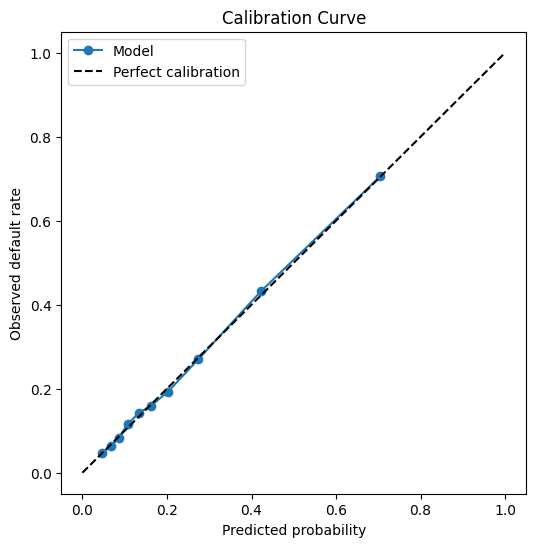

In [89]:
probs = cross_val_predict(xgb, X_train, y_train, cv=5, method="predict_proba")[:, 1]
prob_true, prob_pred = calibration_curve(y_train, probs, n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.xlabel("Predicted probability")
plt.ylabel("Observed default rate")
plt.title("Calibration Curve")
plt.legend()
plt.show()

**The three tree ensembles were statistically tied on cross-validated average precision (0.5611–0.5637, fold standard deviation ≈0.022). XGBoost was selected on calibration: its predicted probabilities deviate from observed default rates by at most 0.0097, against 0.0135 for gradient boosting and 0.0269 for random forest. Calibration is the deciding criterion because the deployed decision threshold is derived from a cost matrix, and that arithmetic is only valid if a predicted probability corresponds to a real default rate. This is also the reason resampling techniques such as SMOTE were rejected — they distort predicted probabilities and would have invalidated the cost calculation.**

In [90]:
oof_probs = cross_val_predict(xgb, X_train, y_train, cv=5, method="predict_proba")[:, 1]

COST_FN = 30_000
COST_FP = 2_000
CAPACITY = 0.05

rows = []
for t in np.arange(0.02, 0.96, 0.01):
    pred = (oof_probs >= t).astype(int)
    fn = ((pred == 0) & (y_train == 1)).sum()
    fp = ((pred == 1) & (y_train == 0)).sum()
    rows.append({"threshold": round(t, 2),
                 "flag_rate": pred.mean(),
                 "cost": fn * COST_FN + fp * COST_FP})

sweep = pd.DataFrame(rows)
unconstrained = sweep.loc[sweep["cost"].idxmin()]
feasible = sweep[sweep["flag_rate"] <= CAPACITY]
constrained = feasible.loc[feasible["cost"].idxmin()]

print("Unconstrained:", unconstrained.to_dict())
print("Constrained:", constrained.to_dict())

Unconstrained: {'threshold': 0.07, 'flag_rate': 0.8398131153011847, 'cost': 35832000.0}
Constrained: {'threshold': 0.71, 'flag_rate': 0.04838978808610045, 'cost': 132928000.0}


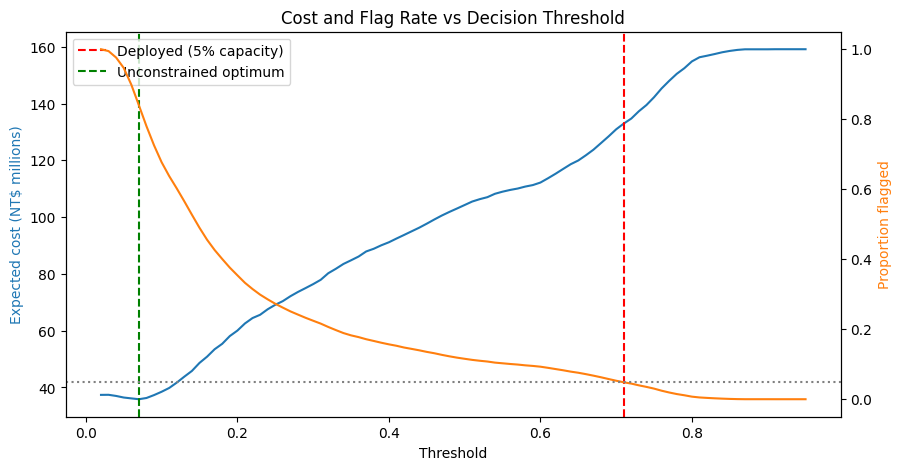

In [91]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(sweep["threshold"], sweep["cost"] / 1e6, color="tab:blue")
ax1.set_xlabel("Threshold")
ax1.set_ylabel("Expected cost (NT$ millions)", color="tab:blue")
ax1.axvline(0.71, color="red", linestyle="--", label="Deployed (5% capacity)")
ax1.axvline(0.07, color="green", linestyle="--", label="Unconstrained optimum")

ax2 = ax1.twinx()
ax2.plot(sweep["threshold"], sweep["flag_rate"], color="tab:orange")
ax2.axhline(0.05, color="grey", linestyle=":")
ax2.set_ylabel("Proportion flagged", color="tab:orange")

ax1.legend(loc="upper left")
plt.title("Cost and Flag Rate vs Decision Threshold")
plt.show()

In [92]:
for cap in [0.02, 0.05, 0.10, 0.20, 0.30]:
    f = sweep[sweep["flag_rate"] <= cap]
    best = f.loc[f["cost"].idxmin()]
    print(f"capacity {cap:.0%}: threshold {best['threshold']:.2f}, "
          f"cost NT${best['cost']/1e6:.1f}m")

capacity 2%: threshold 0.77, cost NT$148.0m
capacity 5%: threshold 0.71, cost NT$132.9m
capacity 10%: threshold 0.57, cost NT$110.0m
capacity 20%: threshold 0.33, cost NT$81.8m
capacity 30%: threshold 0.23, cost NT$65.6m


The model's contribution is worth roughly NT$0.06 per customer in average precision terms. The operational capacity constraint is worth NT$97m. Improving collections capacity from 5% to 10% of the book would reduce expected annual losses by NT$22.9m — an order of magnitude more than any achievable improvement in model performance.

In [93]:
xgb.fit(X_train, y_train)
test_probs = xgb.predict_proba(X_test)[:, 1]
test_pred = (test_probs >= 0.71).astype(int)

print("ROC AUC:", roc_auc_score(y_test, test_probs))
print("Average precision:", average_precision_score(y_test, test_probs))
print(confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred, digits=3,
                            target_names=["no default", "default"]))

ROC AUC: 0.7782947630437517
Average precision: 0.5548041007926903
[[4590   77]
 [1093  233]]
              precision    recall  f1-score   support

  no default      0.808     0.984     0.887      4667
     default      0.752     0.176     0.285      1326

    accuracy                          0.805      5993
   macro avg      0.780     0.580     0.586      5993
weighted avg      0.795     0.805     0.754      5993



In [94]:
import sklearn
import json

In [95]:
joblib.dump(xgb, "model.pkl")

metadata = {
    "model_type": "XGBClassifier",
    "threshold": 0.71,
    "capacity_limit": 0.05,
    "cost_fn": COST_FN,
    "cost_fp": COST_FP,
    "cv_average_precision": 0.5637,
    "test_average_precision": 0.5548,
    "test_roc_auc": 0.7783,
    "calibration_max_deviation": 0.0097,
    "sklearn_version": sklearn.__version__,
}
json.dump(metadata, open("metadata.json", "w"), indent=2)

In [96]:
loaded_model = joblib.load("model.pkl")
loaded_meta = json.load(open("metadata.json"))

# A raw customer record, exactly as an API would receive it.
# No scaling, no encoding, no transforms applied by hand.
customer = {
    "LIMIT_BAL": 50000, "SEX": 2, "EDUCATION": 2, "MARRIAGE": 1, "AGE": 29,
    "PAY_0": 2, "PAY_2": 2, "PAY_3": 2, "PAY_4": 0, "PAY_5": 0, "PAY_6": 0,
    "BILL_AMT1": 48000, "BILL_AMT2": 47000, "BILL_AMT3": 46000,
    "BILL_AMT4": 45000, "BILL_AMT5": 44000, "BILL_AMT6": 43000,
    "PAY_AMT1": 1500, "PAY_AMT2": 1500, "PAY_AMT3": 1200,
    "PAY_AMT4": 1000, "PAY_AMT5": 1000, "PAY_AMT6": 1000,
}

new = pd.DataFrame([customer])
new["months_delinquent"] = (new[ordinal] > 0).sum(axis=1)
new["max_delinquency"] = new[ordinal].max(axis=1)
new["over_limit"] = (new["BILL_AMT1"] > new["LIMIT_BAL"]).astype(int)

prob = loaded_model.predict_proba(new)[0, 1]
print(f"Probability of default: {prob:.3f}")
print(f"Threshold: {loaded_meta['threshold']}")
print("Decision:", "FLAG" if prob >= loaded_meta["threshold"] else "NO ACTION")

Probability of default: 0.685
Threshold: 0.71
Decision: NO ACTION


In [97]:
audit = pd.DataFrame({
    "sex": X_test["SEX"].values,
    "actual": y_test.values,
    "flagged": (test_probs >= 0.71).astype(int),
})

audit.groupby("sex").agg(n=("actual", "size"),
                         actual_rate=("actual", "mean"),
                         flag_rate=("flagged", "mean"))

,n,actual_rate,flag_rate
sex,,,
1,2332,0.243997,0.058748
2,3661,0.206774,0.047255


In [98]:
for s, g in audit.groupby("sex"):
    fn_rate = ((g.flagged == 0) & (g.actual == 1)).sum() / g.actual.sum()
    fp_rate = ((g.flagged == 1) & (g.actual == 0)).sum() / (1 - g.actual).sum()
    print(f"SEX={s}  FN rate {fn_rate:.3f}  FP rate {fp_rate:.3f}")

SEX=1  FN rate 0.824  FP rate 0.021
SEX=2  FN rate 0.824  FP rate 0.014


In [1]:
import os
print(os.getcwd())

C:\Users\zainh\Machine Learning Projects\credit


In [2]:
print(os.listdir())

['.ipynb_checkpoints', 'Credit Project.ipynb', 'Credit risk.ipynb', 'Credit_Card_Default_Risk_Prediction.ipynb', 'metadata.json', 'model.pkl', 'UCI_Credit_Card.csv', 'Untitled.ipynb', 'Untitled1.ipynb']


In [3]:
import os, shutil

for d in ["credit-risk-model/src", "credit-risk-model/model",
          "credit-risk-model/notebooks", "credit-risk-model/data"]:
    os.makedirs(d, exist_ok=True)

print(os.listdir("credit-risk-model"))

['data', 'model', 'notebooks', 'src']


In [4]:
shutil.copy("model.pkl", "credit-risk-model/model/model.pkl")
shutil.copy("metadata.json", "credit-risk-model/model/metadata.json")
shutil.copy("UCI_Credit_Card.csv", "credit-risk-model/data/UCI_Credit_Card.csv")

print(os.listdir("credit-risk-model/model"))

['metadata.json', 'model.pkl']


In [5]:
%%writefile credit-risk-model/src/preprocessing.py
import pandas as pd

ORDINAL = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]


def add_features(df):
    """Engineered features. Must match section 3.2 of the notebook exactly.

    Stateless - no statistics learned from the data - so the same function
    can be applied to one incoming API request or to the full training set
    and give identical results.
    """
    df = df.copy()
    df["months_delinquent"] = (df[ORDINAL] > 0).sum(axis=1)
    df["max_delinquency"] = df[ORDINAL].max(axis=1)
    df["over_limit"] = (df["BILL_AMT1"] > df["LIMIT_BAL"]).astype(int)
    return df

Writing credit-risk-model/src/preprocessing.py


In [6]:
import sys
sys.path.insert(0, "credit-risk-model/src")
from preprocessing import add_features
print(add_features.__doc__[:60])

Engineered features. Must match section 3.2 of the notebook 


In [7]:
print(os.listdir("credit-risk-model/src"))

['app.py', 'preprocessing.py', '__pycache__']


In [8]:
%%writefile credit-risk-model/requirements.txt
scikit-learn==1.7.2
xgboost==3.1.2
pandas==2.3.3
numpy==2.2.6
joblib==1.5.2
fastapi==0.141.1
uvicorn[standard]==0.34.0
pydantic==2.13.4

Writing credit-risk-model/requirements.txt


In [9]:
%%writefile credit-risk-model/Dockerfile
FROM python:3.12-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY src/ ./src/
COPY model/ ./model/

WORKDIR /app/src

EXPOSE 8000

CMD uvicorn app:app --host 0.0.0.0 --port ${PORT:-8000}

Writing credit-risk-model/Dockerfile


In [10]:
%%writefile credit-risk-model/.dockerignore
data/
notebooks/
venv/
__pycache__/
*.ipynb
.git/
.ipynb_checkpoints/

Writing credit-risk-model/.dockerignore


In [11]:
print(os.listdir("credit-risk-model"))

['.dockerignore', 'data', 'Dockerfile', 'model', 'notebooks', 'requirements.txt', 'src']


In [12]:
shutil.copy("Credit_risk.ipynb", "credit-risk-model/notebooks/credit_risk.ipynb")
print(os.listdir("credit-risk-model/notebooks"))

['credit_risk.ipynb']


In [14]:
print([f for f in os.listdir() if f.endswith(".ipynb")])

['Credit_Card_Default_Risk_Prediction.ipynb', 'Credit_risk.ipynb']


In [15]:
shutil.copy("Credit_risk.ipynb", "credit-risk-model/notebooks/credit_risk.ipynb")
print(os.listdir("credit-risk-model/notebooks"))


['credit_risk.ipynb']


In [17]:
base = {
    "LIMIT_BAL": 50000, "SEX": 2, "EDUCATION": 2, "MARRIAGE": 1, "AGE": 29,
    "PAY_0": 2, "PAY_2": 2, "PAY_3": 2, "PAY_4": 0, "PAY_5": 0, "PAY_6": 0,
    "BILL_AMT1": 48000, "BILL_AMT2": 47000, "BILL_AMT3": 46000,
    "BILL_AMT4": 45000, "BILL_AMT5": 44000, "BILL_AMT6": 43000,
    "PAY_AMT1": 1500, "PAY_AMT2": 1500, "PAY_AMT3": 1200,
    "PAY_AMT4": 1000, "PAY_AMT5": 1000, "PAY_AMT6": 1000,
}

for feature, values in [("LIMIT_BAL", [10000, 50000, 200000, 500000]),
                        ("PAY_0", [-1, 0, 1, 2, 4]),
                        ("BILL_AMT1", [1000, 20000, 48000, 100000])]:
    print(f"\n{feature}")
    for v in values:
        test = dict(base)
        test[feature] = v
        prob = xgb.predict_proba(add_features(pd.DataFrame([test])))[0, 1]
        print(f"  {feature}={v}: {prob:.4f}")


LIMIT_BAL


NameError: name 'xgb' is not defined